## Assignment 2: $k$ Nearest Neighbor

### Do any four.

In [1]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()


Download complete
Extracting data files...
Data extracted


**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?

In simple terms, if the target/outcome variable y is numerical, it is a regression. If this variable is categorical, then this is a classification.

2. What is a confusion table/matrix? What does it help us understand about a model's performance?

A confusion table/matrix is essentially a table we can generate that shows a cross-tabulation of the true labels with the predicted results to see if they are aligned. This helps us better understand the model's overall performance in terms of how close it got, which is a key metric in machine learning. Essentially, it is evaluating fit and whether this model is actually making good or bad predictions. Sometimes a confusion table/matrix is paired with accuracy to generate a summary number.

3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?

Accuracy is essentially a proportion of the cases we predicted correctly. This is the sum of the number of cases on the descending diaganol on the confusion matrix divided by the total number of observations. This might not be entirely sufficient to evaluate a predictive performance as it fundamentally fails to capture the kinds of errors it is making and possibly can mask poor performance on one type of category completely if it is too low of a proportion. Pure accuracy fails to weigh the kinds of errors and the test cases that matter properly and equate them mathematically which can be faulty.

4. What does the root mean squared error quantify about a particular model?

The root mean squared error quanitifies essentially how far off the model was from reality in its predictions. It tells you how far off it was on average compared to the true values.

5. What are overfitting and underfitting?

Overfitting means we pick a k value that is way too low so the model is overly sensitive. Underfitting means we pick a k value that is way too high so the model just ends up giving values very close to the population proportions.

6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?

Splitting the data into trianing and testing sets is very practical as it still allows you to create and fine tune the model while still having a plethora of "test" values that resemble ideally the real world values the model would be getting. Ultimately this also enables us to test the model on data it has not been trained on which is a key principle. Evaluating accuracy or RMSE as factors to determine the k is also going to improve model performance as this allows you to experimentally test and optimize the k value that gives you the least error.

7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

A class label is simple and easy to interpret as the model is committing to a final answer. Practically, you could make the case that the model should strive to give a final interpretable answer in the form of a class label as well as a distribution of probabilities is less decisive. On the other hand, a distribution of probabilities might more accurately highlight the thought process of the model and show more clearly the different weighings of each option rather than mask what possibly could be a very close choice. In a pure fine-tuning lens it might be possible that the probability distribution is more useful due to more information while in a practical setting, you might want a class label due to its clarity.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).

The data set appears pretty small and notably, some variables seem almost standardized which is to be expected. Voltage seems to follow a gradient pattern with certain numerical thresholds while height and soil tends to follow what looks like fixed standards according to the shape of the scatter plots. There is a roughly even split between each mine type.

2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

Done.

3. Build a $k$-NN classifier. Explain how you select $k$.

If I try to analyze the optimal k value testing every possible k, you end up with optimal k values that are very high and very likely underfitting the data. Regardless, the optimal k value that is the same efficiency but is the lowest among these is 139. That still seems high, but that could also speak to the general efficacy of my model.  

4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?

The accuracy is really low based on the confusion matrix. For some of the classifications, it failed to get any correct and only for some classifications (mine_type 2 and 3) was there some correct predictions. The performance is more accurate for classifying specifically mine_type 2 and mine_type 3 and is unable to predict in any meaningful sense the other three mine_types. Overall, I would say the performance quality is low and that "height" may not be a great variable to test with a KNN for this data set.


5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In practice, I would not suggest anyone use this model as it stands taking "height" into consideration. The level of inaccurate predictions is extremely high and the fact it was able to make zero accurate predictions for more than half of the mine_types indicates that this is not an effective model despite a sound and logical code structure. I would advise someone to test a different variable such as voltage or perhaps soil type to better classify mine_types.

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


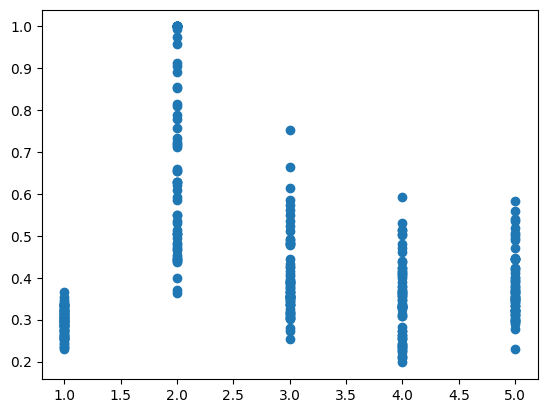

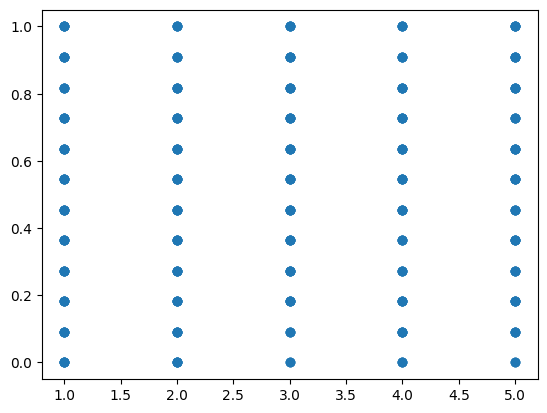

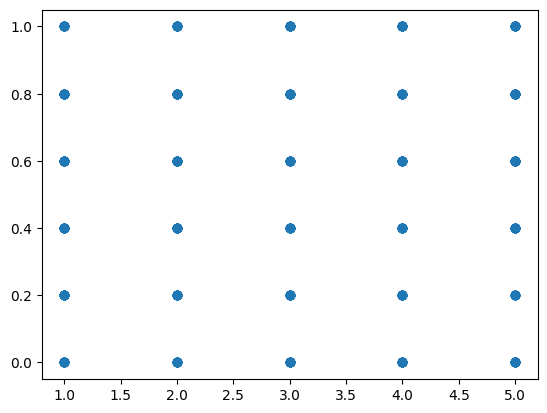

between variables that determine output


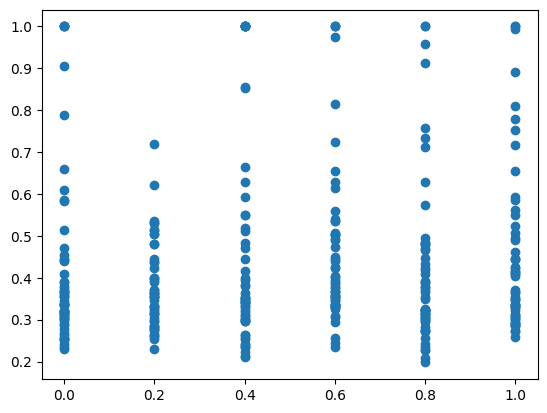

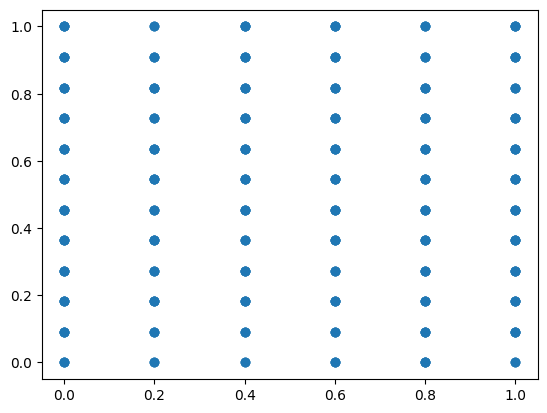

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/data/land_mines.csv")
print(df.head())

print(df.describe())

print(df["mine_type"].value_counts())

plt.scatter(df["mine_type"], df["voltage"])
plt.show()
plt.scatter(df["mine_type"], df["height"])
plt.show()
plt.scatter(df["mine_type"], df["soil"])
plt.show()
print("between variables that determine output")
plt.scatter(df["soil"], df["voltage"])
plt.show()
plt.scatter(df["soil"], df["height"])
plt.show()

In [48]:
from sklearn.model_selection import train_test_split
df_train, df_test, y_train, y_test = train_test_split(df[["height"]],df["mine_type"],test_size=.5,random_state=100)
k = 139
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors = k)
model = model.fit(df_train,y_train)
y_hat = model.predict(df_test)
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_hat))
model.score(df_test,y_test)

[[ 0 20 17  0  0]
 [ 0 17 14  0  0]
 [ 0  7 19  0  0]
 [ 0 18 15  0  0]
 [ 0 21 21  0  0]]


0.21301775147928995

Test accuracy for 3 neighbors is 0.17159763313609466; train accuracy for 3 neighbors is 0.25443786982248523
Test accuracy for 5 neighbors is 0.15384615384615385; train accuracy for 5 neighbors is 0.27218934911242604
Test accuracy for 7 neighbors is 0.1242603550295858; train accuracy for 7 neighbors is 0.28402366863905326
Test accuracy for 9 neighbors is 0.1242603550295858; train accuracy for 9 neighbors is 0.2958579881656805
Test accuracy for 11 neighbors is 0.11834319526627218; train accuracy for 11 neighbors is 0.30177514792899407
Test accuracy for 13 neighbors is 0.11242603550295859; train accuracy for 13 neighbors is 0.3076923076923077
Test accuracy for 15 neighbors is 0.11242603550295859; train accuracy for 15 neighbors is 0.3136094674556213
Test accuracy for 17 neighbors is 0.10650887573964497; train accuracy for 17 neighbors is 0.3136094674556213
Test accuracy for 19 neighbors is 0.13609467455621302; train accuracy for 19 neighbors is 0.28402366863905326
Test accuracy for 21 nei

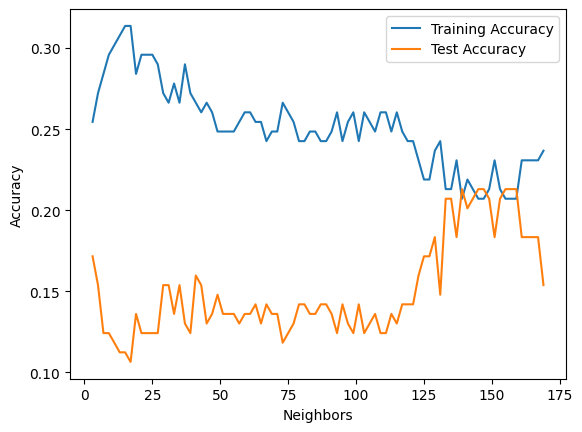

[139 145 147 155 157 159]


In [49]:
k_grid = np.array([ (2*k+3) for k in range(0,84)])
test_accuracies = []
train_accuracies = []
for k in k_grid:
    model = KNeighborsClassifier(n_neighbors = k)
    model = model.fit(df_train,y_train)
    y_hat = model.predict(df_test)
    test_acc = model.score(df_test,y_test)
    train_acc = model.score(df_train,y_train)
    print( f'Test accuracy for {k} neighbors is {test_acc}; train accuracy for {k} neighbors is {train_acc}')
    test_accuracies.append(test_acc)
    train_accuracies.append(train_acc)

sns.lineplot(x=k_grid,y=train_accuracies,label='Training Accuracy').set(xlabel='Neighbors',ylabel='Accuracy')
sns.lineplot(x=k_grid,y=test_accuracies,label='Test Accuracy')
plt.show()

is_optimal = test_accuracies == np.max(test_accuracies)
optimal_indices = np.where( is_optimal )
k_optimal = k_grid[ optimal_indices ]
print(k_optimal)

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)